<a href="https://colab.research.google.com/github/ImagingDataCommons/idc-nlst-plus/blob/main/TechnicalValidation/consistencyChecks/NLSTSegVSNLSTSybil_viz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Visualize the comparison between NLSTSeg lesion segmentations to the NLST Sybil bounding boxes

In this notebook, we visualize the comparison of the lesion segmentations from NLSTSEg to the Sybil bounding boxes.

Deepa Krishnaswamy

Brigham and Women's Hospital

August 2026

# Set up the environment

In [1]:
import matplotlib.pyplot as plt
import re
import seaborn as sns
import pandas as pd
import numpy as np

# Download the csv file from GitHub

The 'nlstseg_ts_lesion_matching_with_volume.csv' is created from the 'NLSTSegVsTs.ipynb' notebook. For simplicity, the csv file has been uploaded to GitHub

In [2]:
!wget https://raw.githubusercontent.com/ImagingDataCommons/idc-nlst-plus/refs/heads/main/TechnicalValidation/consistencyChecks/nlst_sybil_and_nlstseg_overlap_per_series.csv

--2026-08-11 21:38:40--  https://raw.githubusercontent.com/ImagingDataCommons/idc-nlst-plus/refs/heads/main/TechnicalValidation/consistencyChecks/nlst_sybil_and_nlstseg_overlap_per_series.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 309856 (303K) [text/plain]
Saving to: ‘nlst_sybil_and_nlstseg_overlap_per_series.csv’

nlst_sybil_and_nlst 100%[===================>] 302.59K  --.-KB/s    in 0.03s   

2026-08-11 21:38:40 (9.03 MB/s) - ‘nlst_sybil_and_nlstseg_overlap_per_series.csv’ saved [309856/309856]



# Create a plot to compare NLSTSeg lesions vs TS regions

In [3]:
csv_filename = "/content/nlst_sybil_and_nlstseg_overlap_per_series.csv"
df = pd.read_csv(csv_filename)

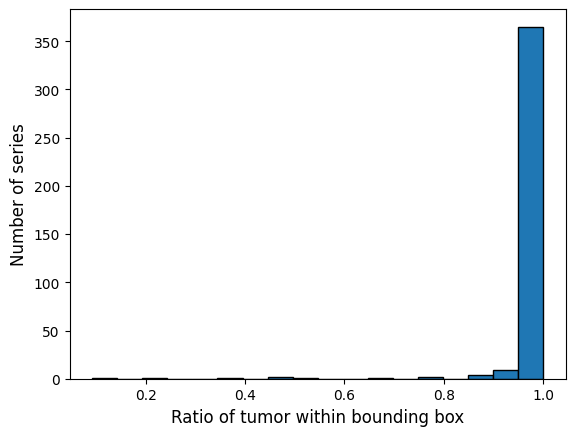

In [4]:
ax = sns.histplot(data=df, x="overlap_metric", binwidth=0.05, alpha=1)
ax.set_xlabel("Ratio of tumor within bounding box", fontsize=12)
ax.set_ylabel("Number of series", fontsize=12)
plt.show()

# Create a precision/recall plot

In [5]:
# Calculate the precision and recall

# Slice Recall (Sensitivity): fraction of segmentation slices covered by boxes
df["slice_recall"] = np.where(
    df["num_of_slices_with_seg"] > 0, df["number_of_slices_with_bbox_and_seg"] / df["num_of_slices_with_seg"], np.nan
)

# Slice Precision: fraction of bounding box slices that contain segmentation
df["slice_precision"] = np.where(
    df["num_of_slices_with_bbox"] > 0, df["number_of_slices_with_bbox_and_seg"] / df["num_of_slices_with_bbox"], np.nan
)

# Calculate axial IoU (1D Jaccard Index across slices)
df["iou_z"] = np.where(
    (df["num_of_slices_with_seg"] + df["num_of_slices_with_bbox"] - df["number_of_slices_with_bbox_and_seg"]) > 0,
    df["num_of_slices_with_bbox"] / (df["num_of_slices_with_seg"] + df["num_of_slices_with_bbox"] - df["number_of_slices_with_bbox_and_seg"]),
    0.0,
)

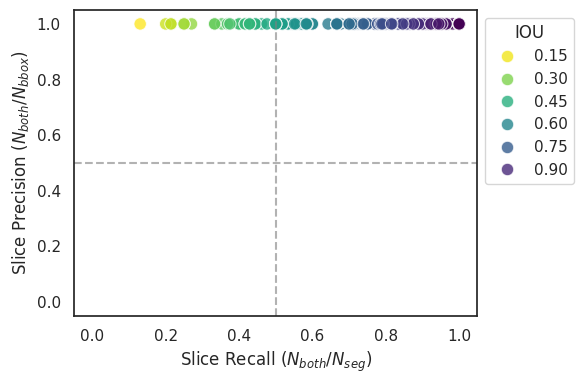

In [6]:
# Plot figure

plt.figure(figsize=(6, 4))
sns.set_theme(style="white")

# Scatter plot (hue colors points by 1D axial IoU)
ax = sns.scatterplot(
    data=df.dropna(subset=["slice_recall", "slice_precision"]),
    x="slice_recall",
    y="slice_precision",
    hue="iou_z",
    palette="viridis_r",
    s=80,
    alpha=0.8,
)

# Reference quadrant lines
plt.axhline(0.5, color="gray", linestyle="--", alpha=0.6)
plt.axvline(0.5, color="gray", linestyle="--", alpha=0.6)

# Move legend to outside the plot on the right
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1), title="IOU")

# Axis labels and limits
# plt.title(
#     "NLSTSeg vs. NLST-Sybil: Axial Slice Overlap Analysis",
#     fontsize=13,
#     fontweight="bold",
#     pad=12,
# )

plt.xlabel("Slice Recall ($N_{both} / N_{seg}$)", fontsize=12)
plt.ylabel("Slice Precision ($N_{both} / N_{bbox}$)", fontsize=12)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)

plt.tight_layout()
plt.show()

In [7]:
# Save CSV
df.to_csv("/content/nlst_sybil_and_nlstseg_overlap_per_series_with_iou.csv")

In [8]:
# Download CSV
from google.colab import files
df.to_csv("/content/nlst_sybil_and_nlstseg_overlap_per_series_with_iou.csv", index=False)